# Task 1: Dimensionality Reduction

In this task you will work with the “Labeled Faces in the Wild” data set. You can use
sklearn.datasets.fetch_lfw_people to download the data set (this function might take
a while to run for the first time as it will download the data set).

## Subtask 1: Data Loading and Data Preparation

Load the data set using the arguments min_faces_per_person=30, resize=0.5. Report
the following:
□ How many different people are in the data?
□ How many images are in the data?
□ What is the size of the images?
□ Plot images of ten different people in the data set.
For the remaining tasks, split the data into 70% for training and 30% for validation. Use
the stratified option of sklearn.model_selection.train_test_split (provide the class labels).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA as skPCA
from sklearn.neural_network import MLPRegressor

In [ ]:
lfw_people = fetch_lfw_people(min_faces_per_person=30, resize=0.5, color=False)

# Data extraction
X = lfw_people.data
y = lfw_people.target
target_names = lfw_people.target_names

1. Number of different people: 34
2. Total number of images: 2370
3. Image size (height x width): (62, 47)


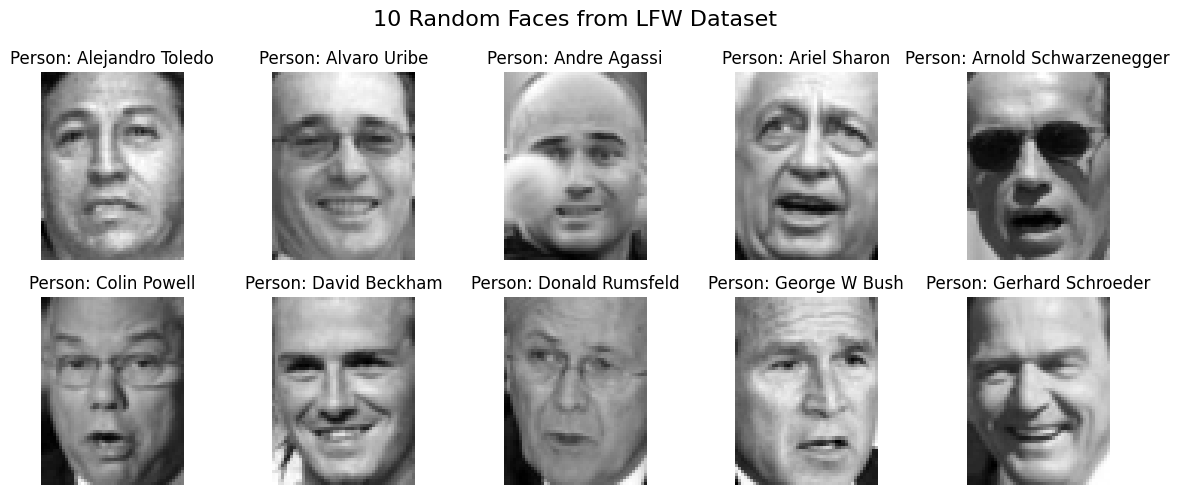

Training set size: 1659
Test set size: 711
Data preparation completed.



In [12]:
print(f"1. Number of different people: {len(target_names)}")
print(f"2. Total number of images: {X.shape[0]}")
print(f"3. Image size (height x width): {lfw_people.images.shape[1:]}")

# 10 random figures visualization
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('10 Random Faces from LFW Dataset', fontsize=16)

unique_people = np.unique(y)
selected_indices = []
for person_id in unique_people[:10]:
    person_indices = np.where(y == person_id)[0]
    selected_indices.append(np.random.choice(person_indices))

for idx, ax in enumerate(axes.flat):
    img_idx = selected_indices[idx]
    ax.imshow(lfw_people.images[img_idx], cmap='gray')
    ax.set_title(f"Person: {target_names[y[img_idx]]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Split on training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print("Data preparation completed.\n")

In [13]:
class PCA:
    # Principal component analysis class
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.explained_variance = None

    def fit(self, X):
        # training
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Covariance matrix calc
        cov_matrix = np.cov(X_centered.T)
        # SVD
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        explained_variance = (S ** 2) / (X.shape[0] - 1)
        components = Vt

        # Choice of top-d components
        self.components = components[:self.n_components]
        self.explained_variance = explained_variance[:self.n_components]

        return self

    def transform(self, X):
       # projection onto principle components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components.T)

    def inverse_transform(self, X_transformed):
        #reconstruction fro projection
        X_reconstructed = np.dot(X_transformed, self.components)
        return X_reconstructed + self.mean

    def get_explained_variance_ratio(self):
        return self.explained_variance / np.sum(self.explained_variance)

In [31]:
def plot_principal_components(pca, n_components=5):
    # function for visualization of n principal components
    image_height, image_width = 62, 47

    fig, axes = plt.subplots(1, n_components, figsize=(15, 3))

    for i in range(n_components):
        component = pca.components[i].reshape(image_height, image_width)
        component_norm = (component - component.min()) / (component.max() - component.min())

        axes[i].imshow(component_norm, cmap='gray')
        axes[i].set_title(f'PC {i+1}\n({pca.explained_variance[i]:.2e})')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def plot_reconstructions(X_original, X_test, y_test, pca_model, d, n_images=10, image_shape=(62, 47)):
    # function for visualization of reconstructed
    X_projected = pca_model.transform(X_test)
    X_reconstructed = pca_model.inverse_transform(X_projected)

    fig, axes = plt.subplots(2, n_images, figsize=(20, 4))

    for i in range(n_images):
        # original image
        original = X_test[i].reshape(image_shape)
        axes[0, i].imshow(original, cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        # reconstructed image
        reconstructed = X_reconstructed[i].reshape(image_shape)
        axes[1, i].imshow(reconstructed, cmap='gray')
        axes[1, i].set_title(f'Reconstructed (d={d})')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

In [20]:
dimensions = [5, 10, 20, 40, 80, 160, 320, 640]
pca_models = {}
results = []
for d in dimensions:
  pca = PCA(n_components=d)
  pca.fit(X_train)
  pca_models[d] = pca
  total_variance = np.sum(pca.explained_variance)
  variance_ratio = np.sum(pca.get_explained_variance_ratio())
  print(f"Explained variance: {variance_ratio:.4f} ({variance_ratio*100:.2f}%)")
  # Maing projections
  X_train_proj = pca.transform(X_train)
  X_test_proj = pca.transform(X_test)
  # Normalization
  scaler = MinMaxScaler()
  X_train_proj_scaled = scaler.fit_transform(X_train_proj)
  X_test_proj_scaled = scaler.transform(X_test_proj)
  # Logistic regression classifier training
  clf = LogisticRegression(
            max_iter=5000,
            random_state=42,
            n_jobs=-1
        )
  clf.fit(X_train_proj_scaled, y_train)
    # Accuracy evaluation
  train_accuracy = clf.score(X_train_proj_scaled, y_train)
  test_accuracy = clf.score(X_test_proj_scaled, y_test)
  print(f"Accuracy training: {train_accuracy:.4f}")
  print(f"Accuracy test: {test_accuracy:.4f}")
  results.append({
            'd': d,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'variance_ratio': variance_ratio
        })

Explained variance: 1.0000 (100.00%)
Accuracy training: 0.2393
Accuracy test: 0.2391
Explained variance: 1.0000 (100.00%)
Accuracy training: 0.2948
Accuracy test: 0.2827
Explained variance: 1.0000 (100.00%)
Accuracy training: 0.3707
Accuracy test: 0.3404
Explained variance: 1.0000 (100.00%)
Accuracy training: 0.5606
Accuracy test: 0.4838
Explained variance: 1.0000 (100.00%)
Accuracy training: 0.7372
Accuracy test: 0.5584
Explained variance: 1.0000 (100.00%)
Accuracy training: 0.8674
Accuracy test: 0.5851
Explained variance: 1.0000 (100.00%)
Accuracy training: 0.9620
Accuracy test: 0.5640
Explained variance: 1.0000 (100.00%)
Accuracy training: 0.9988
Accuracy test: 0.5148


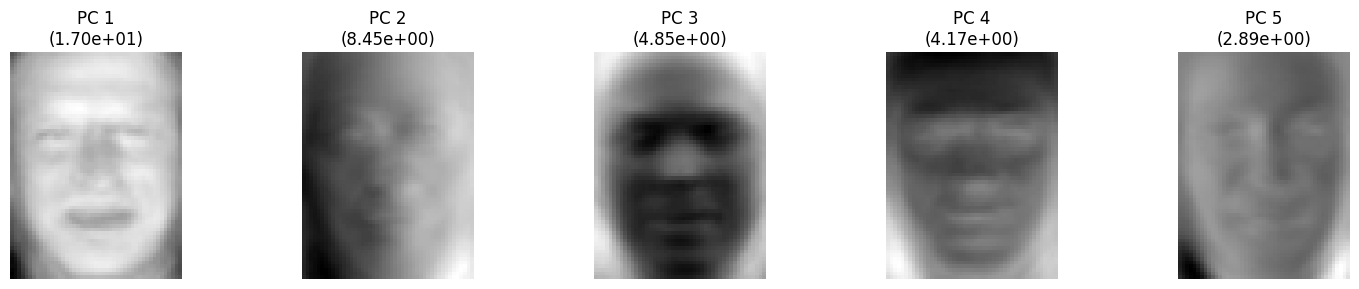

In [29]:
# top 5 principal component visualization
plot_principal_components(pca_models[320], n_components=5)

Reconstruction for d=5...


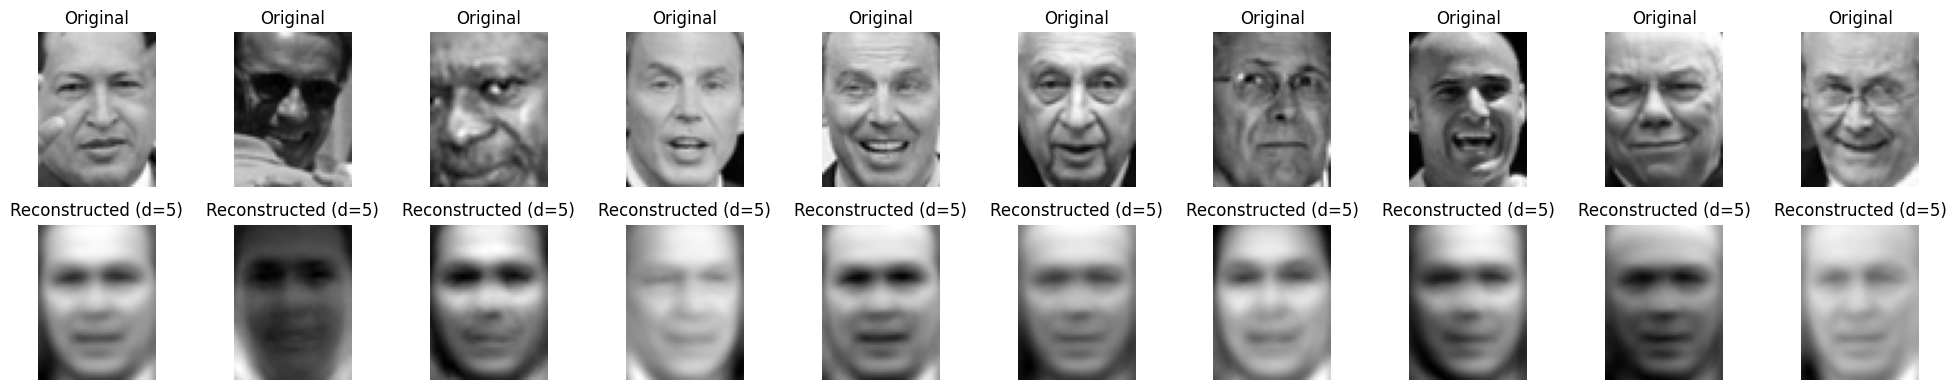

Reconstruction for d=10...


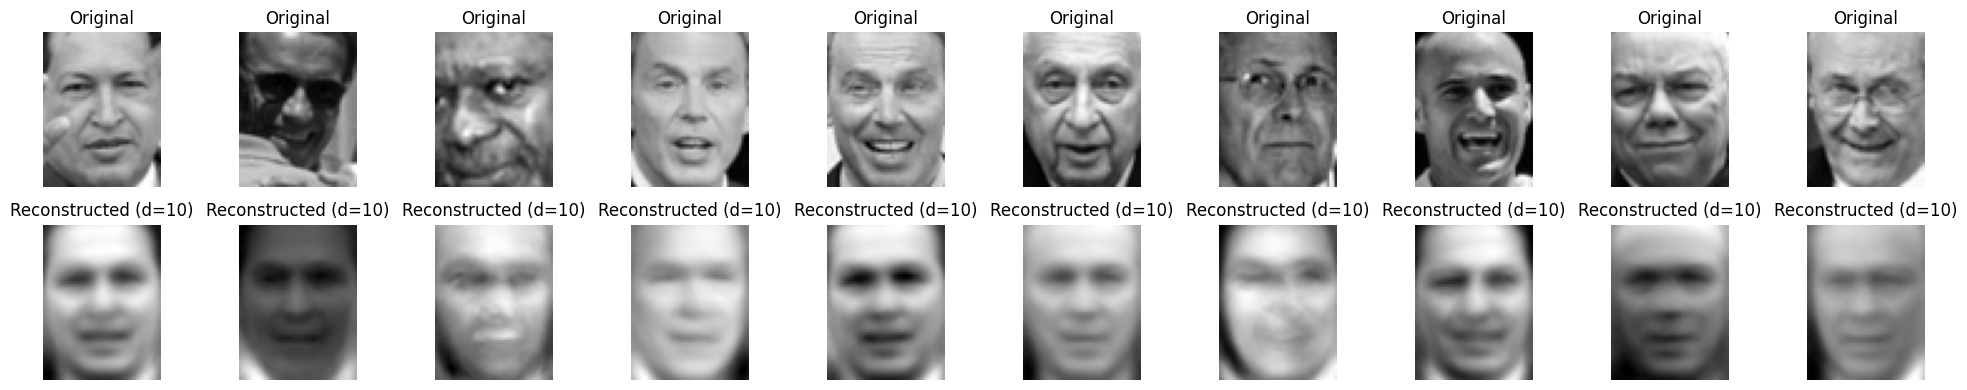

Reconstruction for d=20...


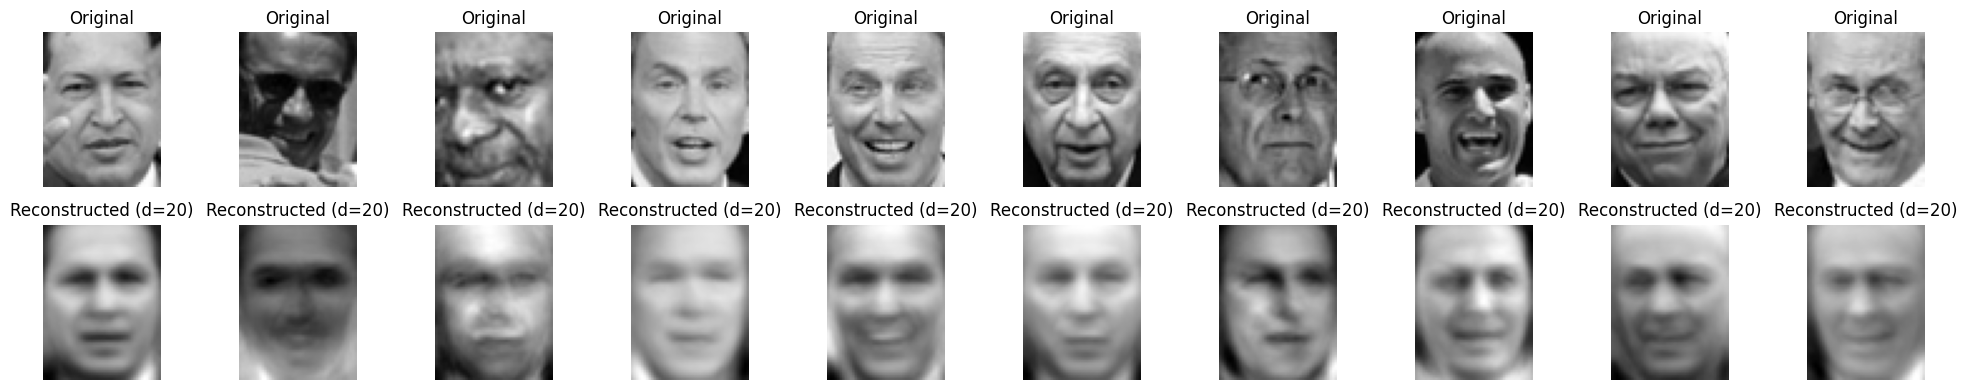

Reconstruction for d=40...


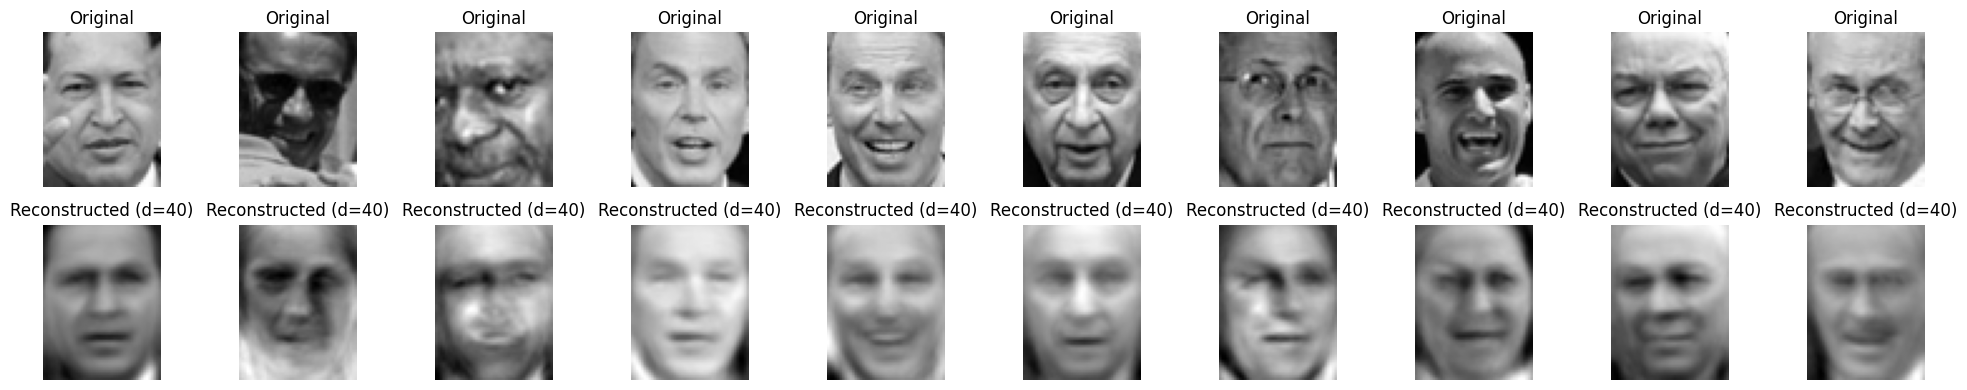

Reconstruction for d=80...


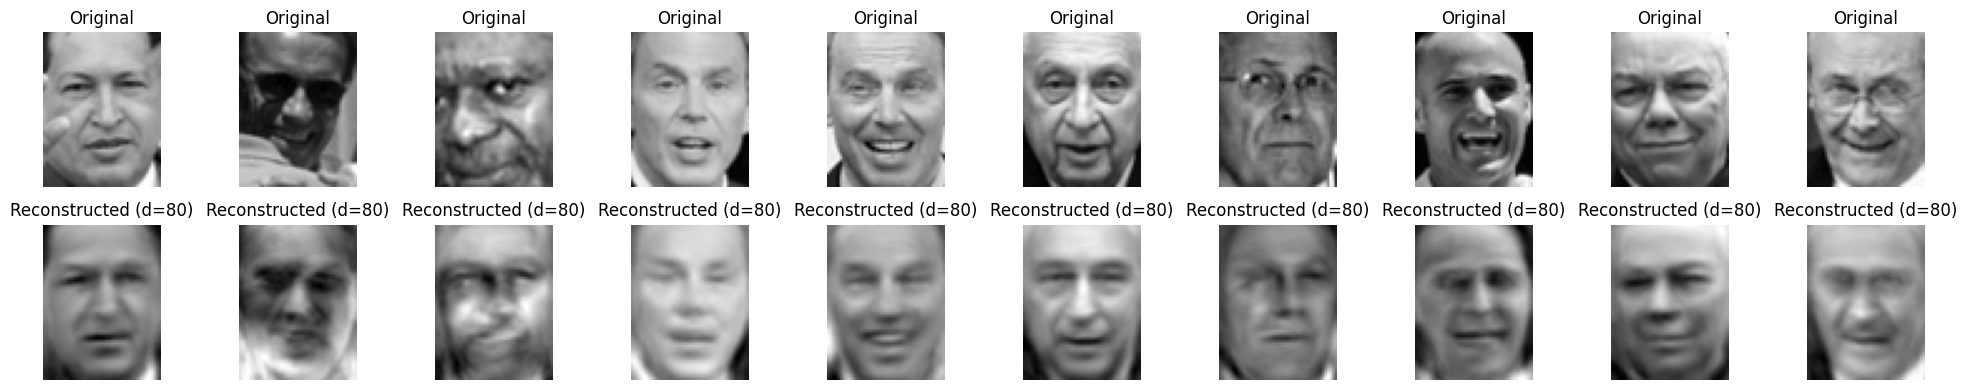

Reconstruction for d=160...


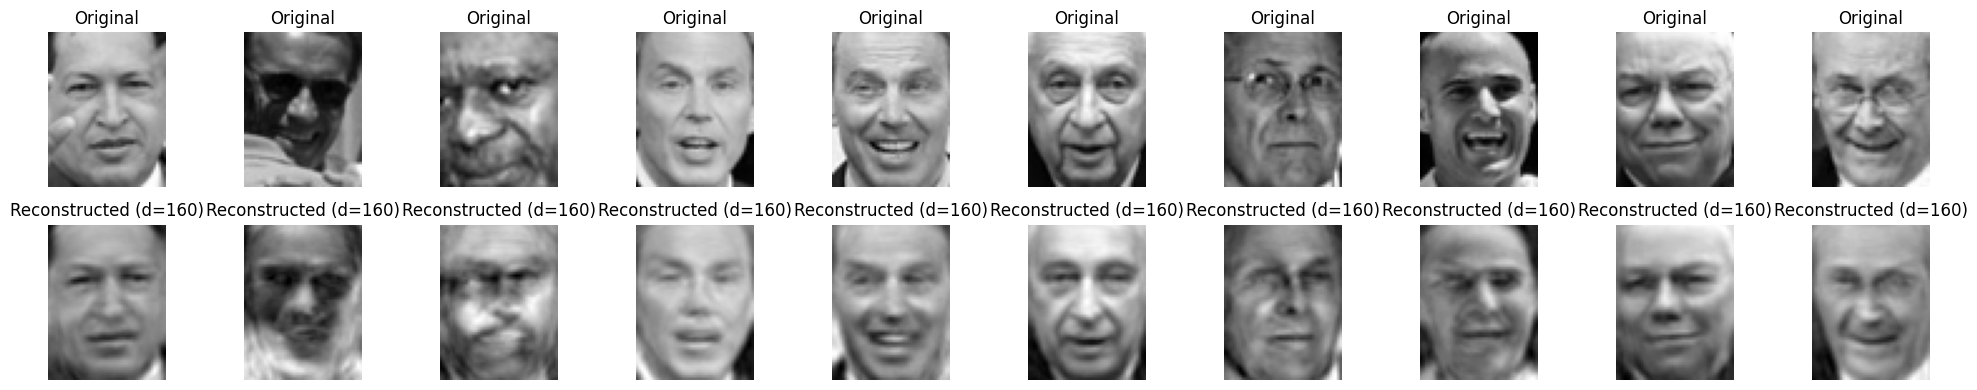

Reconstruction for d=320...


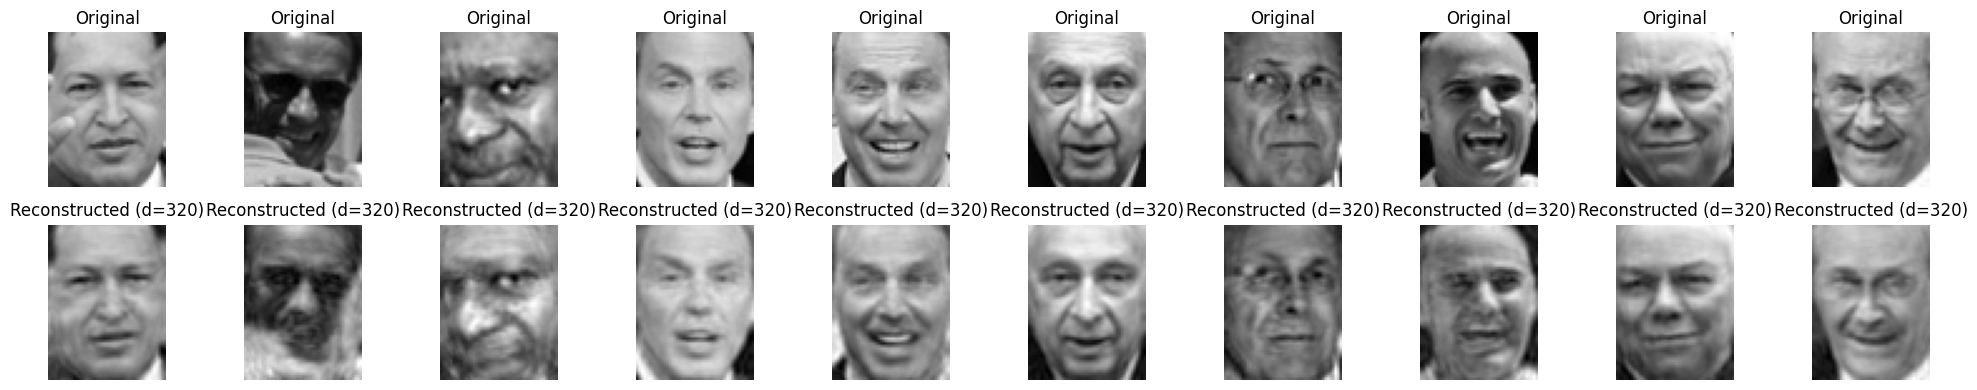

Reconstruction for d=640...


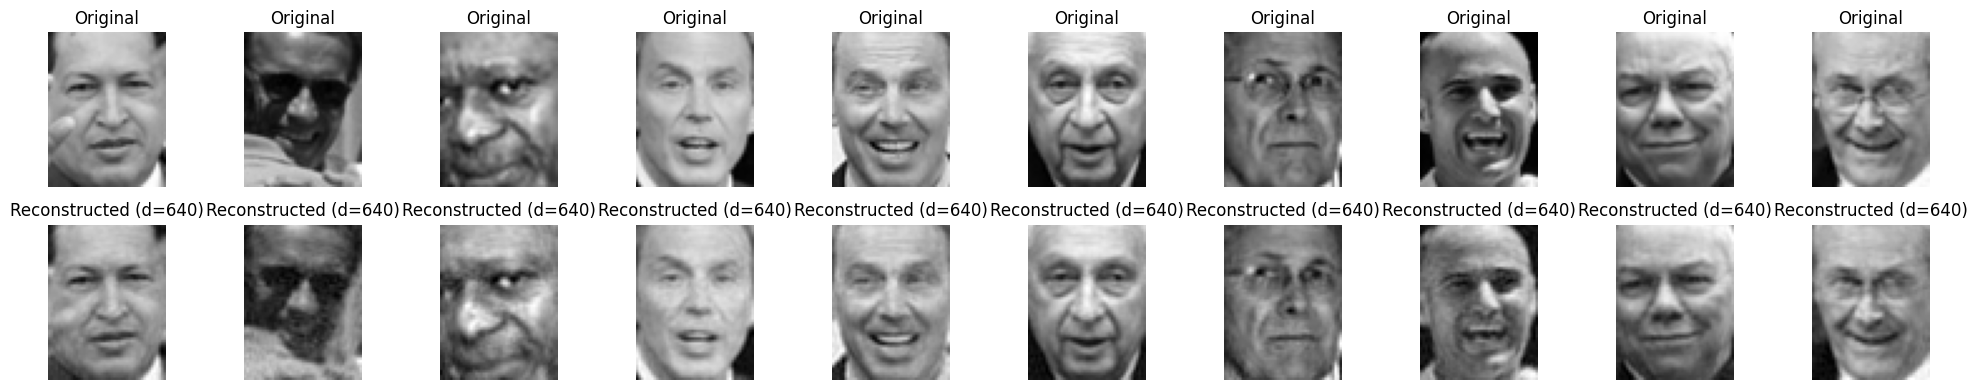

In [32]:
# reconstructions visualization
for d in dimensions:
    print(f"Reconstruction for d={d}...")
    plot_reconstructions(X_train, X_test, y_test, pca_models[d], d, n_images=10)

5        1.0000       0.2393       0.2391      
10       1.0000       0.2948       0.2827      
20       1.0000       0.3707       0.3404      
40       1.0000       0.5606       0.4838      
80       1.0000       0.7372       0.5584      
160      1.0000       0.8674       0.5851      
320      1.0000       0.9620       0.5640      
640      1.0000       0.9988       0.5148      


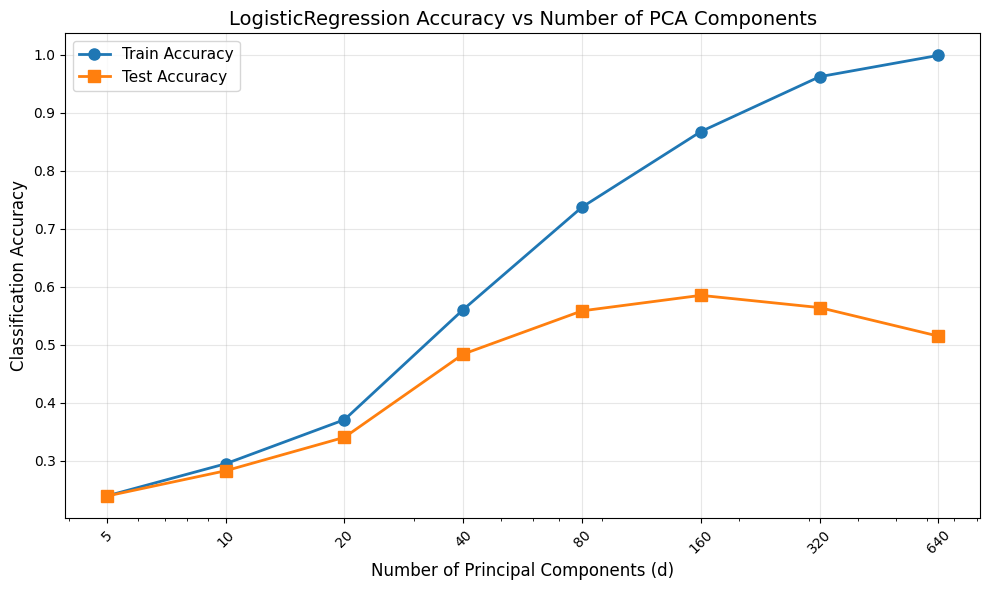

In [33]:
# classification results
for result in results:
  print(f"{result['d']:<8} {result['variance_ratio']:<12.4f} "
    f"{result['train_accuracy']:<12.4f} {result['test_accuracy']:<12.4f}")
dimensions_plot = [r['d'] for r in results]
train_accs = [r['train_accuracy'] for r in results]
test_accs = [r['test_accuracy'] for r in results]
plt.figure(figsize=(10, 6))
plt.semilogx(dimensions_plot, train_accs, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.semilogx(dimensions_plot, test_accs, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Number of Principal Components (d)', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.title('LogisticRegression Accuracy vs Number of PCA Components', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(dimensions_plot, dimensions_plot, rotation=45)
plt.tight_layout()
plt.show()

The accuracy for test sample steadily improves from 5 to 160 number of principal components. However, the most rapid increase in accuracy we can observe between 20 and 40 dimensions.
With visual part we can notice that the reconstrcution is quite bad for PC number lower than 160 espesially for some images. The most part of the images become more or less similar to the original ones with 160-320 dimensions.

## Subtask 3: Dimensionality Reduction Using Autoencoders

Use sklearn to train autoencoders for dimensionality reduction. In particular use the sklearn.neural_network.MLPRegressor class with hidden sizes of (a, b, d, b, a) for a, b ∈ N, d ∈ {40, 80} and rectified linear units. You can then use the following code snippets to encode images (in vector form) and decode images from compressed representations (where mlp denotes the MLPRegressor instance)


In [35]:
def encode(X, mlp):
    """
    Encoding the data onto latent space
    Args:
        X: Matrix (n_images, width*height)
        mlp: MLPRegressor
    Returns:
        Encoded data (n_images, d)
    """
    z = X
    for i in range(len(mlp.coefs_) // 2):
        z = z @ mlp.coefs_[i] + mlp.intercepts_[i]
        z = np.maximum(z, 0)  # ReLU activation
    return z


def decode(Z, mlp):
    """
    Decoding ffrom latent space into original space
    Args:
        Z: Encoded data matrix (n_images, d)
        mlp: MLPRegressor
    Returns:
        Decoded data (n_images, width*height)
    """
    z = Z
    for i in range(len(mlp.coefs_) // 2, len(mlp.coefs_)):
        z = z @ mlp.coefs_[i] + mlp.intercepts_[i]
        if i < len(mlp.coefs_) - 1:
            z = np.maximum(z, 0)  # ReLU activation
    return z

def train_autoencoder(X_train, a, b, d, epochs=300, learning_rate=0.001):
    """
    Autoencoder training
    Args:
        X_train: training data
        a: input layer size
        b: Hidden layer size
        d: Size of latent layer
        epochs: Number of epochs
        learning_rate
    Returns:
         MLPRegressor
    """
    mlp = MLPRegressor(
        hidden_layer_sizes=(b, d, b),
        activation='relu',
        solver='adam',
        learning_rate='adaptive',
        learning_rate_init=learning_rate,
        max_iter=epochs,
        random_state=42,
        early_stopping=False,
        batch_size=32,
        verbose=0
    )
    mlp.fit(X_train, X_train)
    return mlp

In [36]:
def plot_autoencoder_reconstructions(X_original, X_test, mlp, d,
                                     n_images=10, n_features=2914):
    # Visualization of autoencoder reconstructed images
    Z = encode(X_test, mlp)
    X_reconstructed = decode(Z, mlp)
    image_height, image_width = 62, 47

    fig, axes = plt.subplots(2, n_images, figsize=(20, 4))

    for i in range(n_images):
        # original image
        original = X_test[i].reshape(image_height, image_width)
        axes[0, i].imshow(original, cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')
        # Reconstructed image
        reconstructed = X_reconstructed[i].reshape(image_height, image_width)
        axes[1, i].imshow(reconstructed, cmap='gray')
        axes[1, i].set_title(f'AE d={d}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


def evaluate_autoencoder(X_train, X_test, y_train, y_test, mlp, d,
                         n_features=2914):
    # Autoencoder evaluation with classification (Logistic Regressor classifier)
    Z_train = encode(X_train, mlp)
    Z_test = encode(X_test, mlp)

    # normalization
    scaler = MinMaxScaler()
    Z_train_scaled = scaler.fit_transform(Z_train)
    Z_test_scaled = scaler.transform(Z_test)
    clf = LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(Z_train_scaled, y_train)

    # Accuracy evaluation
    train_accuracy = clf.score(Z_train_scaled, y_train)
    test_accuracy = clf.score(Z_test_scaled, y_test)
    print(f"Accuracy train: {train_accuracy:.4f}")
    print(f"Accuracy test: {test_accuracy:.4f}")

    return train_accuracy, test_accuracy


Architecture 1 (b=200)


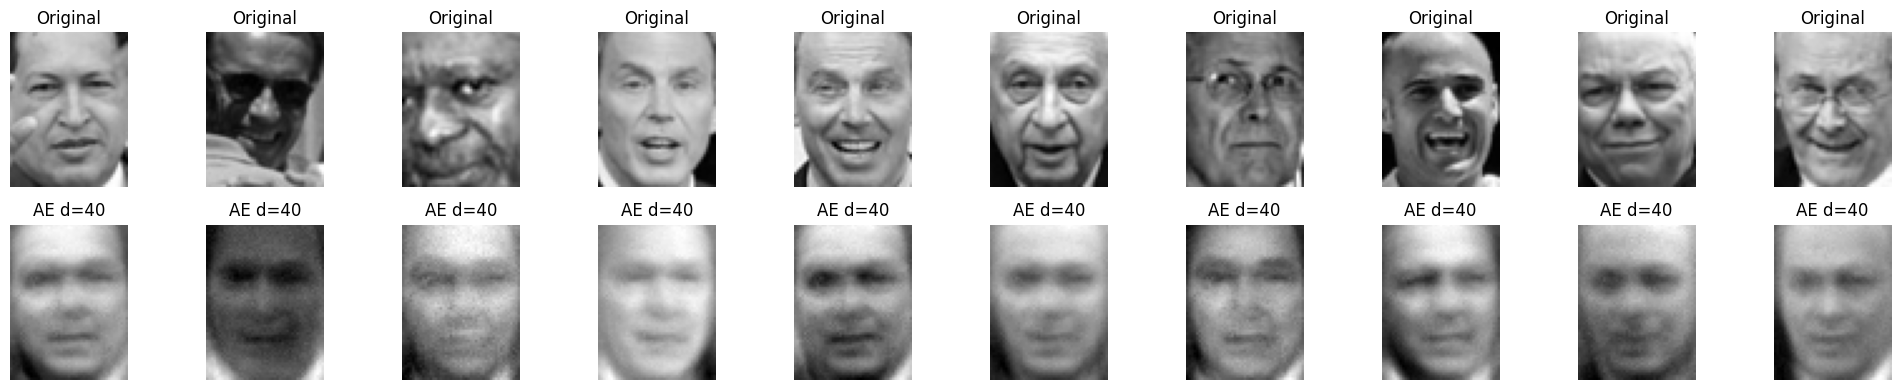

Accuracy train: 0.2797
Accuracy test: 0.2714


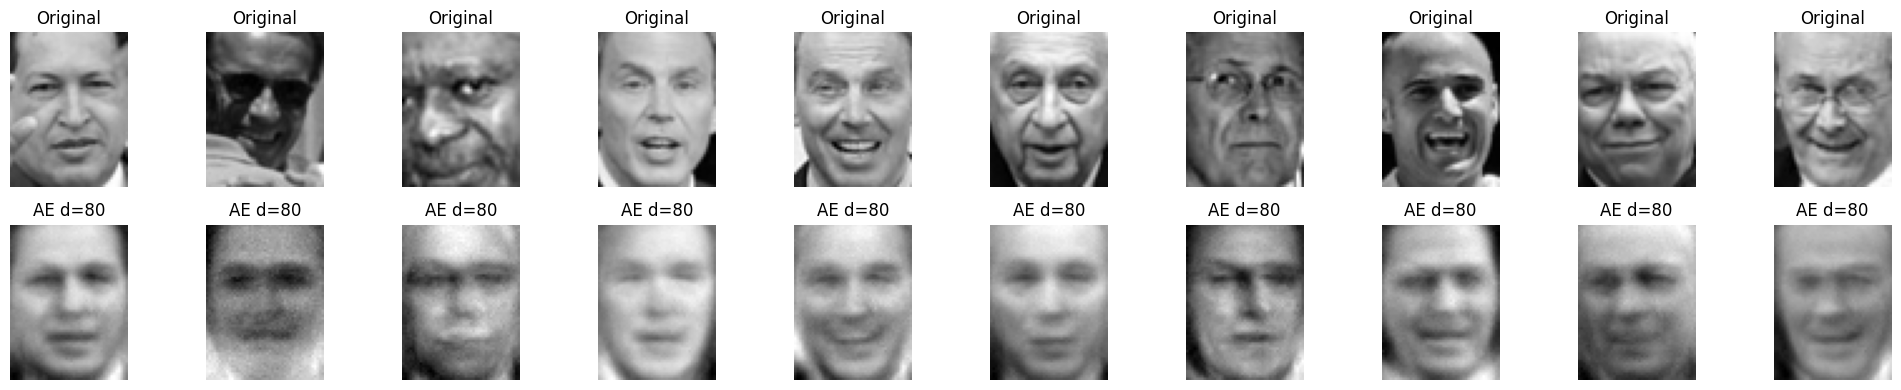

Accuracy train: 0.3906
Accuracy test: 0.3516

Architecture 2  (b=500)


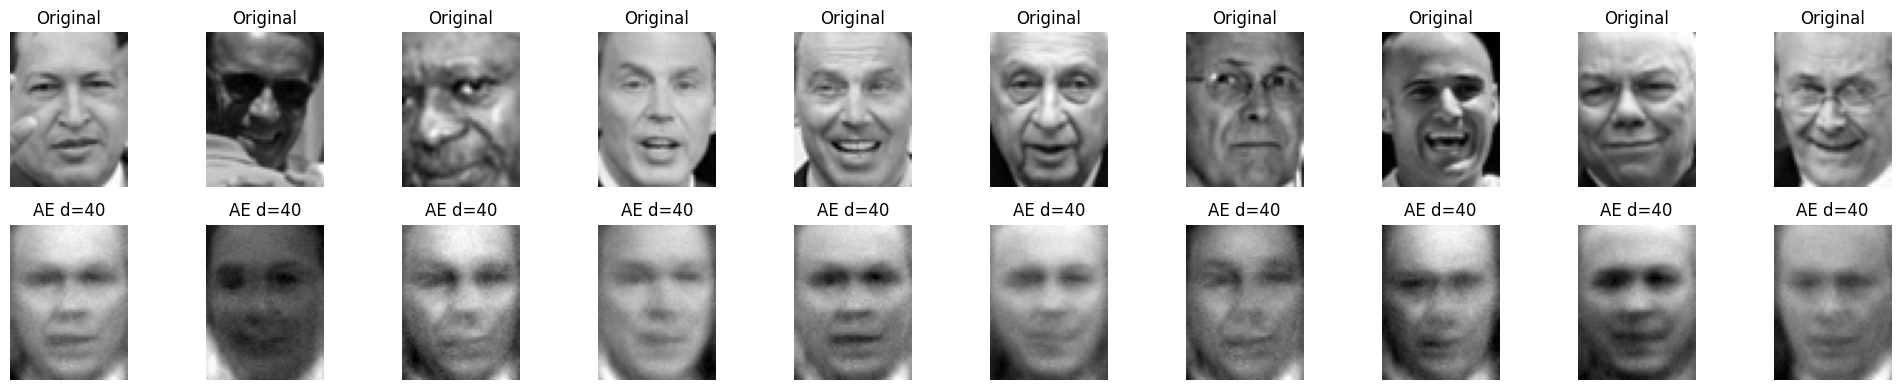

Accuracy train: 0.2622
Accuracy test: 0.2489


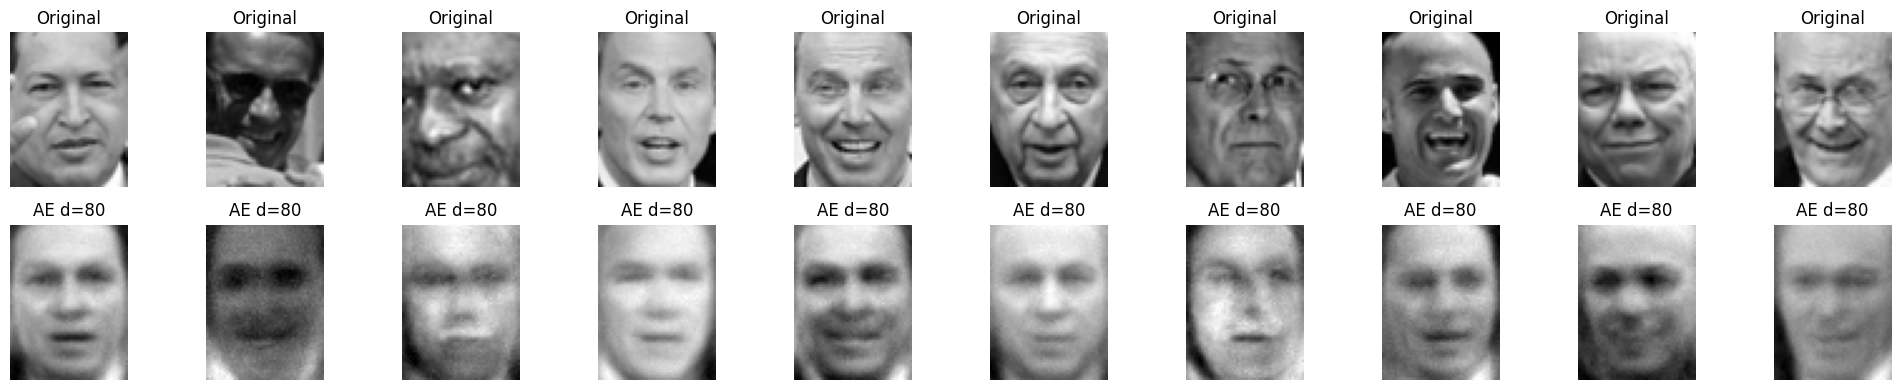

Accuracy train: 0.3297
Accuracy test: 0.3038


In [ ]:
n_features = 2914
architectures = [
        {
            'name': 'Architecture 1',
            'a': n_features,
            'b': 200,
            'd_values': [40, 80],
            'epochs': 300
        },
        {
            'name': 'Architecture 2',
            'a': n_features,
            'b': 500,
            'd_values': [40, 80],
            'epochs': 300
        }
    ]

all_ae_results = []
trained_models = {}
for arch in architectures:
        print(f"\n{arch['name']} (b={arch['b']})")
        arch_results = []
        for d in arch['d_values']:
            # Autoencoder training
            mlp = train_autoencoder(
                X_train,
                a=arch['a'],
                b=arch['b'],
                d=d,
                epochs=arch['epochs'],
                learning_rate=0.001
            )
            # Save model
            model_key = f"{arch['name']} (b={arch['b']}) - d={d}"
            trained_models[model_key] = mlp
            # Reconstruction visualization
            plot_autoencoder_reconstructions(X_train, X_test, mlp, d, n_features=n_features)

            # Evaluation with classifier
            train_acc, test_acc = evaluate_autoencoder(
                X_train, X_test, y_train, y_test, mlp, d, n_features=n_features
            )

            arch_results.append({
                'architecture': arch['name'],
                'b': arch['b'],
                'd': d,
                'train_accuracy': train_acc,
                'test_accuracy': test_acc
            })

        all_ae_results.extend(arch_results)

In [38]:
for result in all_ae_results:
    print(f"{result['architecture']:<30} {result['b']:<6} {result['d']:<6} "
      f"{result['train_accuracy']:<12.4f} {result['test_accuracy']:<12.4f}")


Architecture 1 (Smaller)       200    40     0.2797       0.2714      
Architecture 1 (Smaller)       200    80     0.3906       0.3516      
Architecture 2 (Recommended)   500    40     0.2622       0.2489      
Architecture 2 (Recommended)   500    80     0.3297       0.3038      


**Key observations:**

The second architecture with larger number on hidden layers decreases the accuracy as well as visual interpretation of reconstructed images. Thus, Architecture 1 with a = number of features and b = 200 seems to be recommended. 

Comparing the autoencoder reduction with PCA reduction following observations are noticed. Firstly, the accuracy for test sets in PCA reduction is significantly bigger that in autoencoder reduction. Secondly, the reconstructed images from PCA reduction are less homogeneous (for example, with d=80 some pf the pictures reconstructed good, but others are visually can not be recognised or even identified as humans). At the same time with autoencoder recontruction all the images are more or less identifiable.
